In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [64]:
df = pd.read_csv('Boston.csv')
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [65]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [66]:
X = df.drop('medv', axis=1)
y = df['medv']

In [67]:
X = StandardScaler().fit_transform(X)

In [68]:
lasso = Lasso(alpha=1).fit(X, y)

In [69]:
lasso.coef_, lasso.intercept_

(array([-0.        ,  0.        , -0.        ,  0.        , -0.        ,
         2.7133553 , -0.        , -0.        , -0.        , -0.        ,
        -1.3435488 ,  0.18095664, -3.54338107]),
 np.float64(22.532806324110677))

In [70]:
np.sum(np.abs(lasso.coef_) != 0)

np.int64(4)

In [71]:
c_values = np.logspace(-3, 3, 200)
results = []

for alpha in c_values:
    model = Lasso(alpha=alpha).fit(X, y)
    results.append(model.coef_)

np_results = np.array(results)

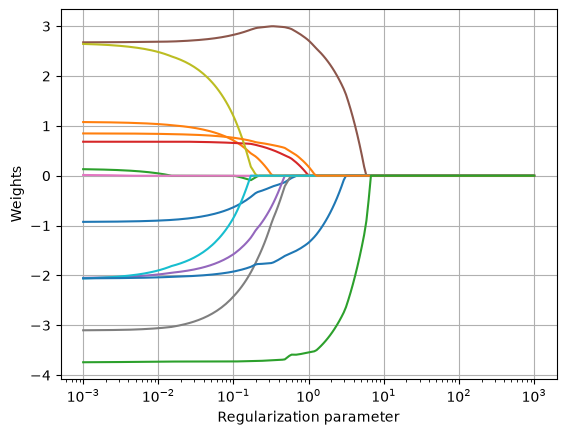

In [72]:
plt.plot(c_values, np_results)
plt.xscale("log")
plt.xlabel("Regularization parameter")
plt.ylabel("Weights")
plt.grid()
plt.show()

In [73]:
Lasso(alpha=10).fit(X, y).coef_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [77]:
def are_weights_zero(C):
    model.set_params(alpha=C)
    model.fit(X, y)

    return np.all(model.coef_ == 0)


a = -4.0
b = 1.0
eps = 1e-7

while (b - a) > eps:
    mid = (a + b) / 2
    C_mid = 10**mid

    if are_weights_zero(C_mid):
        b = mid
    else:
        a = mid

best_t = (a + b) / 2
C_max_dichotomy = 10**best_t

print(f"Минимальное C_max (дихотомия): {C_max_dichotomy}")

Минимальное C_max (дихотомия): 6.681802902808095


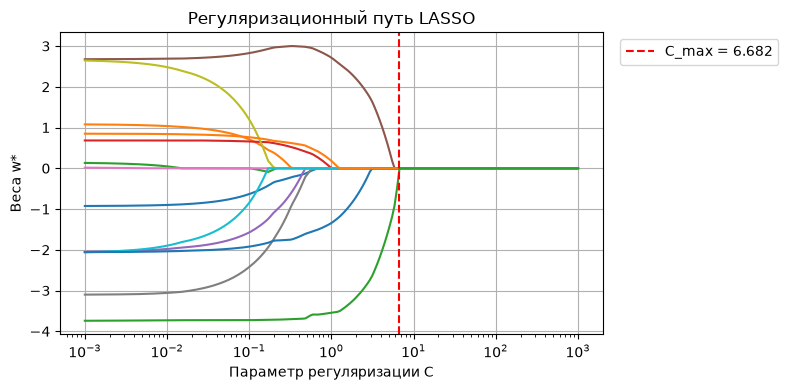

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(c_values, np_results)
plt.axvline(x=C_max_dichotomy, color='red', linestyle='--', label=f"C_max = {C_max_dichotomy:.3f}")
plt.xscale("log")
plt.xlabel("Параметр регуляризации C")
plt.ylabel("Веса w*")
plt.title("Регуляризационный путь LASSO")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()